# A Regularização tipo L1 e L2 aplicada à <br> Regressão Linear

**Autor**: Carlos Gabriel de Oliveira Campos

## Uma breve introdução à Regressão Linear

A Regressão Linear é um algoritmo clássico da estatística que opera ao assumir uma relação linear entre uma ou mais variáveis independentes e uma variável dependente. Em aprendizado de máquina, esse mecanismo *supervisionado* pode ser utilizado para *induzir* modelos preditivos cujo *target* (variável alvo) seja quantitaivo e contínuo, sendo útil para as mais diversas áreas, como:
 
- Imóveis: Prever preços de propriedades usando localização, tamanho e outros fatores.
- Finanças: A previsão de preços de ações usando taxas de juros e dados de inflação.
- Agricultura: Estimar a produção de culturas a partir de chuva, temperatura e qualidade do solo.
- E-commerce: Analisar como preço, promoções e estações afetam as vendas [1].

## Regressão Linear Simples

Para casos de uma única variável independente, chama-se Regressão Linear Simples a relação matemática entre dados que  pode ser representada pela fórmula **1.1**, em que as matrizes-coluna, $Y$ e $X$, representam a resposta quantitativa e a variável de previsão, respectivamente. $\beta_0$ e $\beta_1$ são os coeficientes, sendo o primeiro o *intercepto* - o valor estimado para $Y$ quando todos as variáveis independentes valem 0-, e $\beta_1$, o termo que ajusta as variáveis de X ao valor estimado. Ademais, o termo ϵ simboliza o erro aleatório, com média 0, e simboliza variações naturais que impedem o modelo de prever com total precisão, sendo assim, irredutível.


$$Y = \beta_0 + \beta_1 X + ϵ \tag{1.1}$$

### Calculando os coeficientes

Dado esse modelo, como podemos estimar seus coeficientes? O meio mais prático para essa tarefa é o *Método dos Quadrados Mínimos* (MQM). Para isso, é necessário o conceito de *RSS*, do inglês, *soma dos resíduos quadráticos*. Ela é como um indicador da precisão do modelo, uma *função de custo*! Sendo que uma menor RSS implica em uma maior precisão em relação aos dados de treino. O quadrado da diferença entre o real e o esperado é para que erros de previsão "para mais" e "para menos" não se cancelem, da mesma forma que penaliza mais severamente erros maiores, enquanto suaviza erros menores. 

$$RSS =(y_1 − \hat{\beta}_0 −\hat{\beta}_1x_1)^2+(y_2 −\hat{\beta}_0 −\hat{\beta}_1x_2)^2 + ··· + (y_n − \hat{\beta}_0 − \hat{\beta}_1x_n)^2 \tag{1.2}$$

Quando aplicamos a derivada parcial em relação a cada coeficiente, podemos encontrar que:

$$\hat{\beta}_1 = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2}$$

$$\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x} \tag{1.3}$$



<figure align="center">
  <img src="../../../../../../../../C:/Users/carlos2610010/OneDrive%20-%20ILUM%20ESCOLA%20DE%20CI%C3%8ANCIA/VS%20CODE/2%C2%BA%20SEM/AP.%20MAQ/esfinge/images/rss-graphic.png" alt="Representação gráfica da RSS" width="80%">
  <figcaption><em><b>Figura 1:</b> Representação em contorno e tridimensional da RSS em função dos parâmetros, em que o ponto vermelho corresponde ao par de parâmetros que minimizam a RSS para um certo conjunto de dados. [ISLP - p. 73].</em></figcaption>
</figure>


Notamos, assim, que há uma dependência de $\beta_0$ em relação a $\beta_1$, o que não é favorável aos cálculos para estimar o valor dos coeficientes, visto que qualquer mudança em $\beta_1$ irá alterar $\beta_0$. Logo, é interessante centralizar $X$, o que torna a méida $\tilde{\bar{x}} = 0$.

$$\tilde{x} = x_i - \bar{x}$$
$$\bar{\tilde{x}} = 0$$

Logo:

$$\hat{\beta}_0 = \bar{y}$$

Portanto, podemos reformular a equação (1.2) para:

$$RSS = (\tilde{y_1} − \beta_0 - \hat{\beta}_1 \tilde{x_1})^2 + (\tilde{y_2}−\beta_0 -\hat{\beta}_1\tilde{x_2})^2 + ··· + (\tilde{y_n} - \beta_0 − \hat{\beta}_1\tilde{x_n})^2$$
$$RSS = \sum_{i=1}^{n} (\tilde{y}_i - \beta_0 - \hat{\beta}_1 \tilde{x_i})^2 \tag{1.4}$$


Agora, com a nossa função de custo ajustada, devemos buscar como deve ser o parâmetro $\hat{\beta_1}$ que minimiza a RSS. Ou seja, basta derivar a RSS em relação a $\hat{\beta_1}$ e igualar a 0, obtendo:


$$\tag{1.5}
\hat{\beta_1} = (\tilde{X}^T \tilde{X})^{-1} \tilde{X}^T Y$$

## Colocando em prática: Verificando a relação entre vendas e diferentes meios de publicidade

### Imports de módulos utilizados

In [216]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


### Carregando dados sobre investimento em publicidade para prever o número de vendas

A tabela `Advertising` trata de quantas milhares de unidades de um produto foram vendidas dado uma quantidade em milhar de dólares ($1_000.00) de investimento para cada meio de comunicação para um mercado específico, sendo que estão disponíveis para anúncios `TV`, `radio` e `newspaper` (jornal). 

Dessa forma, a primeira observação da tabela [230.1, 37.8, 69.2, 22.1] indica que em um dado mercado, investiu-se em propagandas - em dólares - 230.1 mil na TV, 37.1 mil nas rádios e 69.2 mil em matérias de jornal, resultando em 22.1 mil unidades vendidas.

In [233]:
# Criando DataFrame do pandas
df = pd.read_csv("Advertising.csv", index_col=0);

### Divisão Treino-Teste pelo método *Holdout*

As observações serão particionadas entre dados para treinamento do modelo e dados para teste do modelo.
Como há apenas 200 observações (um número relativamente baixo), serão reservados 20% dos dados para teste, ao invés dos costumeiros 10% para escalas maiores.

In [218]:
TAMANHO_TESTE = 0.2
SEMENTE = 42 

indices = df.index
indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE,
    random_state=SEMENTE
)

df_treino = df.loc[indices_treino]
df_teste = df.loc[indices_teste]

### Treinamento do modelo

Como será visto em breve, há módulos em python dedicados e bem simples com ferramentas para regressão linear, mas primeiro é necessário pegar a lógica *por debaixo dos panos*.

In [219]:
# Atribuindo cada conjunto a uma Série
x_treino = df_treino["TV"]
y_treino = df_treino["sales"]

x_teste = df_teste["TV"]
y_teste = df_teste["sales"]

# Obtendo médias de X
media_x_treino = x_treino.mean()
media_x_teste = x_teste.mean()

# Centralizando dados da TV
x_treino_c = x_treino - media_x_treino
x_teste_c = x_teste - media_x_teste

# Calculando os parâmetro
b1 = x_treino_c.dot(y_treino) / x_treino_c.dot(x_treino_c)
b0 = y_treino.mean()

# Calcula linha de previsão do modelo
previsao_Y = b0 + x_teste_c * b1

### Visualizando a reta ajustada

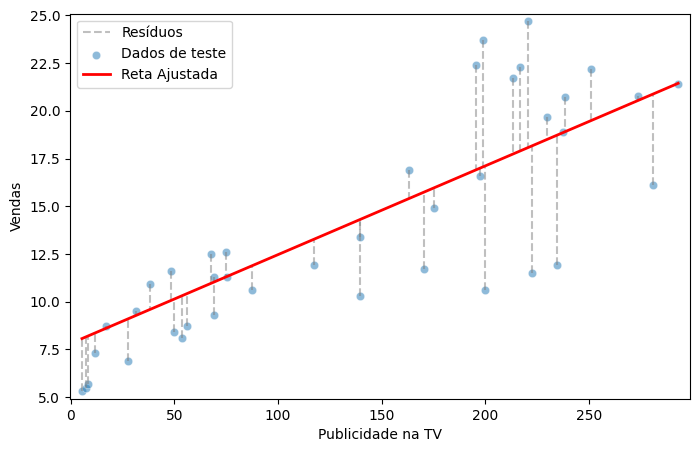

In [220]:
# Ajustes visuais
plt.figure(figsize=(8, 5))
plt.margins(x=0.02, y=0.02)
plt.xlabel("Publicidade na TV")
plt.ylabel("Vendas")

# Adicionando cada linha dos reísudos (IA)
plt.vlines(
    x=x_teste,
    ymin=y_teste,
    ymax=previsao_Y,
    colors="gray",
    linestyles="dashed",
    alpha=0.5,
    label="Resíduos",
)
plt.legend()

# Plota dados de entrada e reta ajustada
eixo = sns.scatterplot(x=x_teste, y=y_teste, alpha=0.5, label="Dados de teste")
sns.lineplot(x=x_teste, y=previsao_Y, color="red", linewidth=2, label="Reta Ajustada");

### O quão forte é a relação entre o atributo e o alvo?

Nas estatísticas, existe uma métrica muito relevante que nos ajuda a compreender a proporção de variabilidade que é explicada pelo modelo, em outras palavras, *o quanto de $Y$ que pode ser explicado por $X$*. Assim, o **coeficiente de determinação**, ou como também é conhecido, $R^2$, é calculado como:

$$R^2 = \frac{TSS - RSS}{TSS} = 1 - \frac{RSS}{TSS}$$

Dado que

$$ TSS = \sum_{i=1}^{n} (y_i - \bar{y})^2$$

Uma medida de $R^2$ próxima de 1 significa que uma vasta proporção da variabilidade dos valores da resposta são explicadas pela regressão, enquanto um resultado próximo de 0 implica que pouco é explicado pela regressão. Isso pode decorrer por um modelo linear errado, por uma variância de erro muito alta, ou por ambos.

In [232]:
r_quad_teste = r2_score(
    y_true=y_teste,
    y_pred=previsao_Y
    )
print(f"R² aferido para dados de teste com RLS: {r_quad_teste:.2f}")

R² aferido para dados de teste com RLS: 0.67


Um $R^2$ de 0.67 indica que apenas a informação de `TV` é capaz de explicar dois terços da variância de $Y$, o que não é um resultado tão satisfatório, trazendo as implicações recém-comentadas, mas demonstra tamanha a relevância dessa mídia para as vendas.


### O quão preciso foi o modelo? Analisando com *RMSE*

De nada adianta treinarmos um modelo, realizar uma previsão, mas não medir seu desempenho. Daí surge a raíz do erro quadrático médio, do inglês *root mean squared error* (RMSE). Ele é uma abrodagem amplamente utilizada por expressar a mesma unidade da variável alvo (nesse caso, unidades vendidas). Por conta de seu fator quadrático, erros maiores são penalizados mais severamente e erros menores são suavizados, o que não o torna a medida mais direta para comunicar o erro médio - como o *erro médio absoluto* (MAE) - [2], mas potencializa comparações entre modelos .

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
\tag{1.6}
$$

$$
MAE = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y_i}| 
\tag{1.7}
$$

Calculando o RMSE:

In [222]:
rmse_rls = root_mean_squared_error(
    y_true=y_teste, 
    y_pred=previsao_Y
    )
print(f"Raíz do erro quadrático médio (RMSE) com Regressão Linear Simples: {rmse_rls:.2f}")

Raíz do erro quadrático médio (RMSE) com Regressão Linear Simples: 3.20


Ou seja, o modelo de regressão linear simples errou, em média, por 2.85 unidades vendidas. 
Dessa forma, pode-se perceber como a publicidade na televisão é um bom preditor para o número de vendas do produto. Ao mesmo tempo, é essencial reconhecer suas imperfeições: ele faz uma análise geral com base em apenas uma única variável, quando, na realidade, há muitos outros fatores que podem influenciar as vendas, como outros meios de publicidade, a imagem pública sobre a marca, etc...

É sempre importante ponderar qual modelo é o mais adequado a cada cenário, e tendo agora uma medida da qualidade do modelo, por que não compará-lo a outro? E se... e se analisarmos mais de um atributo para um mesmo target!? Talvez nossa previsão fique melhor...

## Regressão Linear Múltipla

Como foi sugerido, a Regressão Linear Múltipla (RLM) emerge para induzir modelos com base em 2 *ou mais* preditores simultaneamente. Isso nos permite ter uma compreensão mais profunda das associações entre as variáveis em consideração, mas também requer um novo leque de sensibilidades para trabalhar adequadamente com a nova ferramenta. A base estatística é similar à de Regressão Linear Simples, sendo que a resposta assume a forma:
$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_p X_p + ϵ, \tag{1.6}
$$




Nesse caso, $\hat{\beta}$ simboliza a matriz-coluna dos $p$ coeficientes $(\hat{\beta_1}, \hat{\beta_2}, ...,\hat{\beta_p})^T$, $X$ é a matriz $n$ x $p$ com $n$ variáveis pertencentes a cada um dos $p$ atributos.  
$$
\tag{1.6}
\hat{\beta} = (\tilde{X}^T \tilde{X})^{-1} \tilde{X}^T {Y} 
$$

### Implementação de RLM com `sci-kit`: treinamento

In [223]:
# Atribuindo Pandas/Séries a cada conjunto
X_treino = df_treino[["TV", "radio"]]
y_treino = df_treino["sales"]

X_teste = df_teste[["TV", "radio"]]
y_teste = df_teste["sales"]

# Instanciando modelo
modelo = LinearRegression()

# Treinando modelo
modelo.fit(X_treino, y_treino)

# Gerando previsão
previsao_y = modelo.predict(X_teste)

### Visualização 3D do resultado

*Código gerado pela IA Gemini

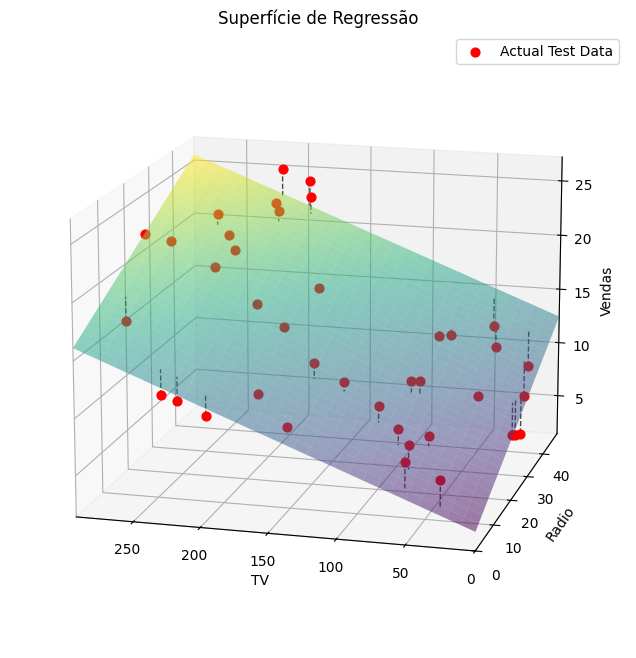

In [224]:
max_tv = X_teste["TV"].max()
max_radio = X_teste["radio"].max()

tv_range = np.linspace(0, max_tv, 30)
radio_range = np.linspace(0, max_radio, 30)
TV_grid, RADIO_grid = np.meshgrid(tv_range, radio_range)

grid_df = pd.DataFrame({
    "TV": TV_grid.ravel(),
    "radio": RADIO_grid.ravel()
})
Z_grid = modelo.predict(grid_df).reshape(TV_grid.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    TV_grid, 
    RADIO_grid, 
    Z_grid, 
    cmap=sns.color_palette("viridis", as_cmap=True),
    edgecolor='none',
    alpha=0.5
)

ax.scatter(
    X_teste["TV"], 
    X_teste["radio"], 
    y_teste, 
    color='red', 
    s=40, 
    label='Actual Test Data',
    depthshade=False
)

for tv, radio, z_actual, z_pred in zip(X_teste["TV"], X_teste["radio"], y_teste, previsao_y):
    ax.plot(
        [tv, tv],
        [radio, radio],
        [z_actual, z_pred],
        color='black', 
        linestyle='--', 
        linewidth=1,
        alpha=0.7
    )

# --- CORREÇÃO DA CONVERGÊNCIA DO PONTO (0,0) ---
ax.set_xmargin(0)
ax.set_ymargin(0)

# Inverter o eixo X faz com que o 0 do TV e o 0 do Radio se encontrem no vértice frontal
ax.set_xlim(max_tv, 0)
ax.set_ylim(0, max_radio)

# Ângulo de câmera ideal para ver o canto (0,0) de frente
ax.view_init(elev=15, azim=-75)

ax.set_xlabel("TV")
ax.set_ylabel("Radio")
ax.set_zlabel("Vendas")
ax.set_title("Superfície de Regressão")
plt.legend()

plt.show()

Olha só! Agora vemos em 3D! Com essa visualização, podemos notar que $\hat{f}(X)$ - o valor previsto - assume um maior valor seguindo a linha reta entre os eixos de Radio e de TV. Isso pode ser compreendido porque ela consiste dos pontos em que o investimento em ambas as modalidades de anúncios são maximizados, logo, as vendas também serão maximizadas. 
Sob outro ponto de vista, dado um orçamento, é notório que deve-se investir mais em propagandas televisivas do que na rádio, uma vez que as primeiras apresentam um maior retorno anúncio-vendas. 

Ao realizar a RLM, agora somos capazes de comparar a efetividade de cada modelo através da medida do RMSE.

In [225]:
rmse_rlm = root_mean_squared_error(
    y_true=y_teste,
    y_pred=previsao_y
)
print(f"Raíz do erro quadrático médio (RMSE) com Regressão Linear Múltipla: {rmse_rlm:.2f} unidades", end="\n\n")

print(f"Razão RMSE R.L. Múltipla / RMSE R.L. Simples: {(rmse_rlm / rmse_rls)*100:.0f}%")

Raíz do erro quadrático médio (RMSE) com Regressão Linear Múltipla: 1.77 unidades

Razão RMSE R.L. Múltipla / RMSE R.L. Simples: 55%


Isso mesmo, o RMSE despencou quase pela metade ao introduzir o novo preditor `radio`! Isso significa um grande avanço ao introduzir

### Calculando o $R^2$

In [231]:
r_quad_rlm = r2_score(
    y_true=y_teste,
    y_pred=previsao_y
    )
print(f"R² aferido para dados de teste com RLM: {r_quad_rlm:.2f}")

R² aferido para dados de teste: 0.90


Uma indagação deve ser feita, pois. E se a empresa dona do produto investisse todo o seu patrimônio em anúncios de TV, ocupando 99% do meio em seu país? Obviamente, a saturação da grade horária deve estagnar a eficácia de mais anúncios, mas perceba que nosso modelo *linear* não é capaz de acompanhar essa desaceleração. 

Mais uma sensibilidade pode ser enfatizada: Será que os anúncios na rádio têm alguma relação com aqueles da TV para influenciar as vendas? Isto é, uma pessoa que ouve e assiste a propaganda em ambos os meios pode ser mais motivada a comprar o produto! Essa interação entre os preditores é denominada **sinergia**!

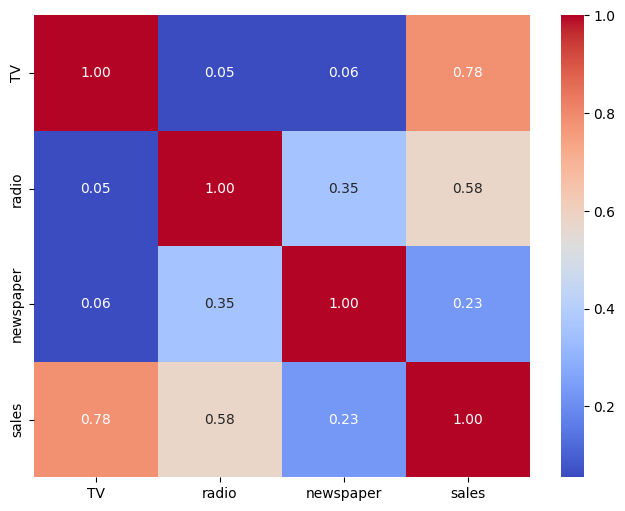

In [227]:
# # Mostra a correlação de Pearson entre todos os preditores
matriz_corr = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [228]:
# Atribuindo Pandas/Séries a cada conjunto
X_treino = df_treino[["TV", "radio", "newspaper"]]
y_treino = df_treino["sales"]

X_teste = df_teste[["TV", "radio", "newspaper"]]
y_teste = df_teste["sales"]

# Instanciando modelo
modelo = LinearRegression()

# Treinando modelo
modelo.fit(X_treino, y_treino)

# Gerando previsão
previsao_y = modelo.predict(X_teste)


In [229]:
rmse_rlm_trn = root_mean_squared_error(
    y_true=y_teste,
    y_pred=previsao_y
)
print(f"Raíz do erro quadrático médio (RMSE) com Regressão Linear Múltipla: {rmse_rlm_trn:.2f} unidades", end="\n\n")

# print(f"Razão RMSE R.L. Múltipla / RMSE R.L. Simples: {(rmse_rlm / rmse_rls)*100:.0f}%")

Raíz do erro quadrático médio (RMSE) com Regressão Linear Múltipla: 1.78 unidades



## Referências

[1] https://www.geeksforgeeks.org/machine-learning/ml-linear-regression/

[2] https://statisticsfundamentals.com/simple-linear-regression/rmse/
